🎯 CNN-ViT HYBRID - Combined Dataset (6 Classes)
Device: cuda
Target Classes: ['plastic', 'metal', 'glass', 'paper', 'cardboard', 'trash']
UWCD Path: /kaggle/input/datasets/siddhantmaji/unified-waste-classification-dataset/content/unified_dataset
Custom Path (primary): /kaggle/input/datasets/hadihebrewshuudu/wasteclass/WasteClassifiaction

📊 DATA PREPROCESSING
✅ Training transforms: with augmentation (applied at load time, every epoch)
✅ Validation/Test transforms: without augmentation

📊 LISTING AND SPLITTING DATASETS (stratified, per source)

📂 Listing: /kaggle/input/datasets/siddhantmaji/unified-waste-classification-dataset/content/unified_dataset
  Available classes: ['metal', 'glass', 'organic_waste', 'battery', 'trash', 'textiles', 'paper_cardboard', 'plastic']
  ✅ metal → metal: 8000 images
  ✅ glass → glass: 8000 images
  ⏭️ Skipping: organic_waste (not in target classes)
  ⏭️ Skipping: battery (not in target classes)
  ✅ trash → trash: 8000 images
  ⏭️ Skipping: textiles (not i

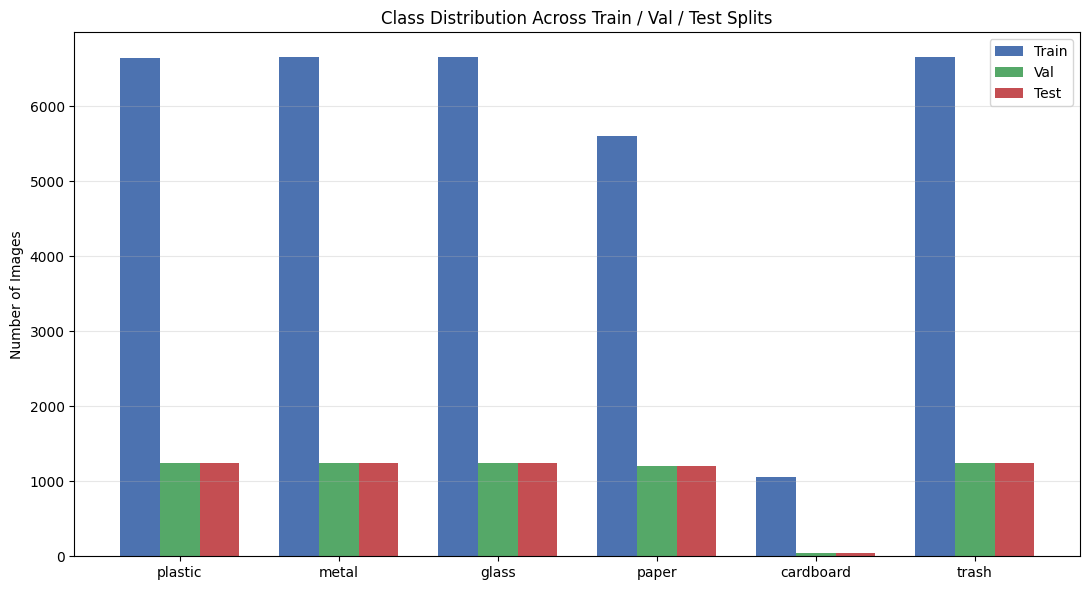

✅ Saved 'class_distribution_splits.png'

🧠 BUILDING CNN-ViT HYBRID MODEL

Initializing CNN (resnet50) + ViT (deit_small_patch16_224)...


  CNN features: 2048
  ViT features: 384
✅ Model built successfully!
   Total parameters: 46,553,286

ℹ️ 1 GPU detected — running on a single device

📊 Model Architecture:
  Device: cuda
  Classes: 6

🎯 TRAINING SETUP
Optimizer: AdamW (lr=0.0001)
Scheduler: CosineAnnealingLR (T_max=30)
Loss: CrossEntropyLoss
Epochs: 100 (max, with early stopping)
Early Stopping: patience=10, min_delta=0.001

🚀 STARTING TRAINING

▶️ No checkpoint found — starting fresh training run.
Epoch [1/100] Batch [10/1040] Loss: 1.6080
Epoch [1/100] Batch [20/1040] Loss: 1.3504
Epoch [1/100] Batch [30/1040] Loss: 1.2240
Epoch [1/100] Batch [40/1040] Loss: 0.9686
Epoch [1/100] Batch [50/1040] Loss: 0.6904
Epoch [1/100] Batch [60/1040] Loss: 0.8926
Epoch [1/100] Batch [70/1040] Loss: 0.6447
Epoch [1/100] Batch [80/1040] Loss: 0.7437
Epoch [1/100] Batch [90/1040] Loss: 0.6749
Epoch [1/100] Batch [100/1040] Loss: 0.6284
Epoch [1/100] Batch [110/1040] Loss: 0.6357
Epoch [1/100] Batch [120/1040] Loss: 0.4318
Epoch [1/10

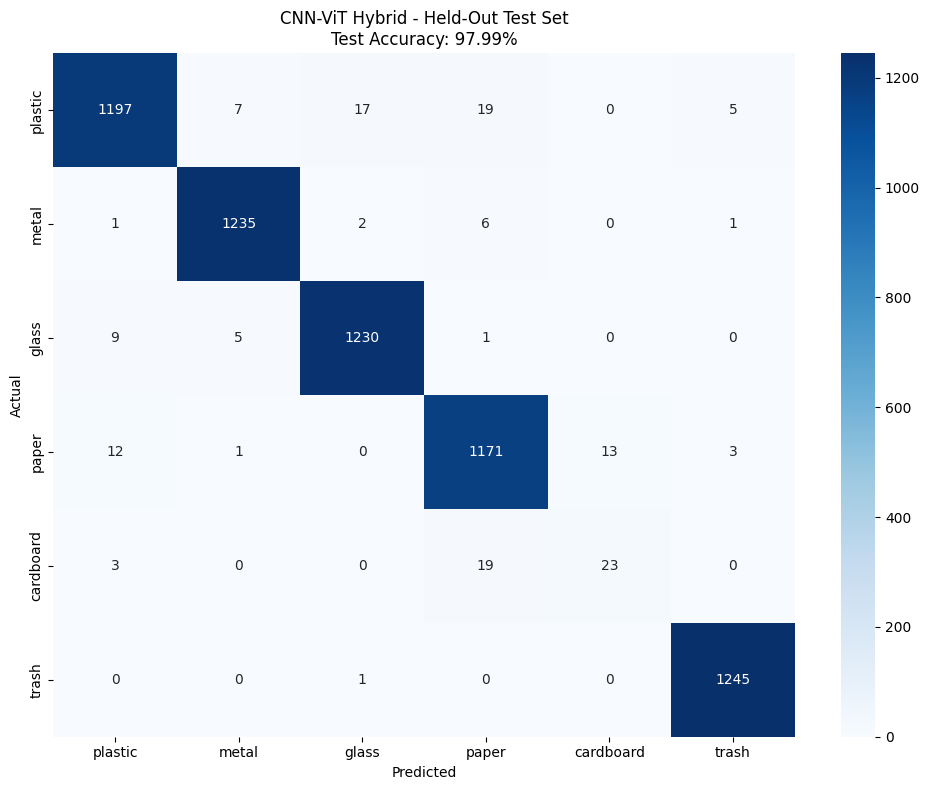


📈 TRAINING VISUALIZATION


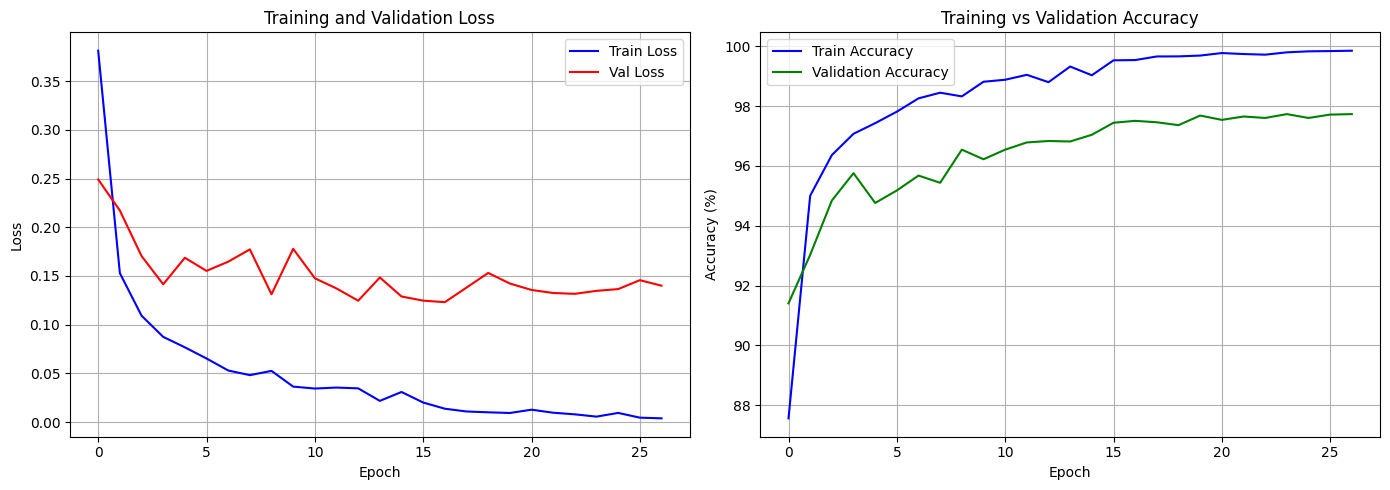


📈 ROC CURVE


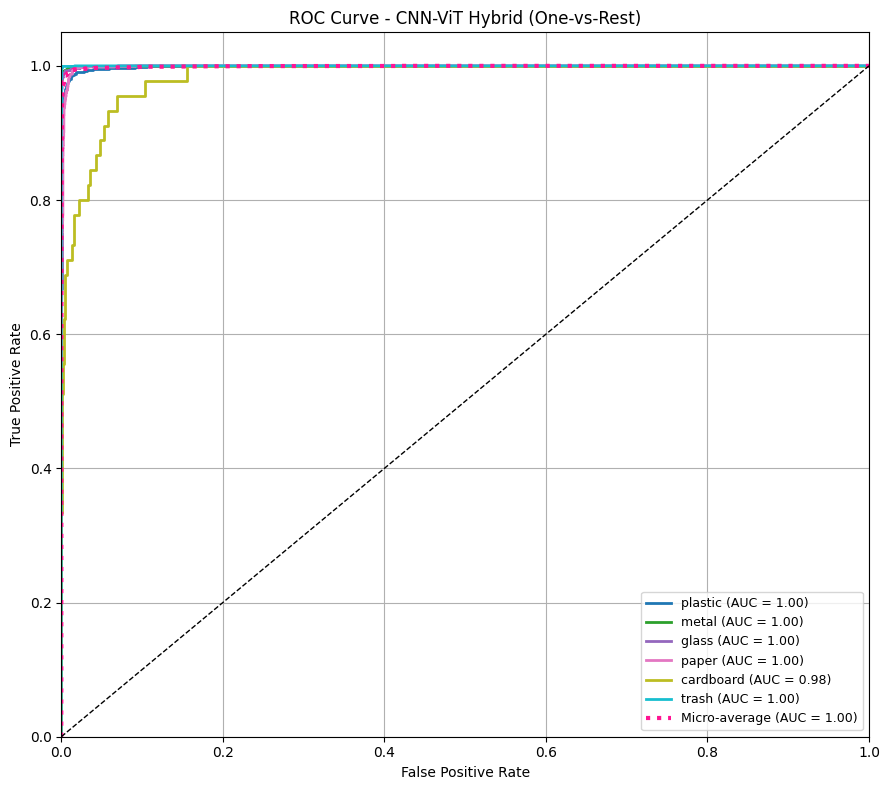


📈 PRECISION-RECALL CURVE


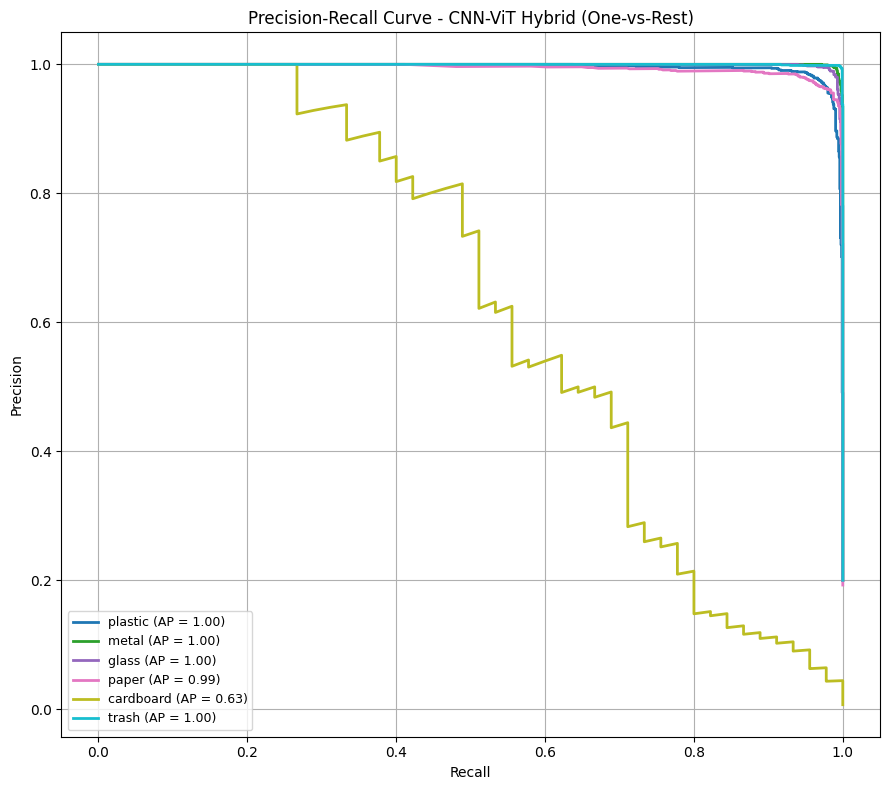


📈 PER-CLASS TEST ACCURACY


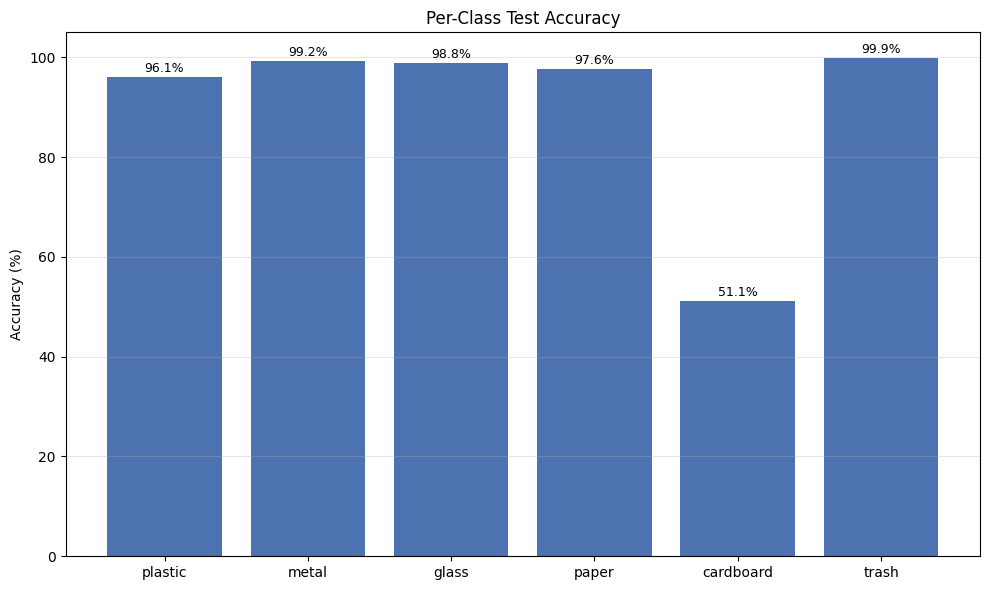

  plastic: 96.1% (1197/1245)
  metal: 99.2% (1235/1245)
  glass: 98.8% (1230/1245)
  paper: 97.6% (1171/1200)
  cardboard: 51.1% (23/45)
  trash: 99.9% (1245/1246)

💾 SAVING MODEL
✅ Model saved as 'cnn_vit_hybrid_6class.pth'
   Test Accuracy: 97.99%
   Best Val Accuracy: 97.73%
✅ Label encoder saved

🎯 INFERENCE FUNCTION

Example inference:

class_name, confidence = predict_image(
    image_path='path/to/test_image.jpg',
    model=model,
    label_encoder=label_encoder,
    transform=val_transform,
    device=DEVICE
)
print(f"Prediction: {class_name} (Confidence: {confidence:.1f}%)")


🎉 CNN-ViT HYBRID TRAINING COMPLETE!


In [1]:
import os
import random
import numpy as np
import pickle
from PIL import Image
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, label_binarize
from sklearn.metrics import (classification_report, confusion_matrix, accuracy_score,
                              roc_curve, auc, precision_recall_curve, average_precision_score)
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import transforms
from torch.utils.data import Dataset, DataLoader, ConcatDataset, WeightedRandomSampler
import timm
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# 1. CONFIGURATION SPECIFIYING FILE PATHS

UWCD_PATH = "/kaggle/input/datasets/siddhantmaji/unified-waste-classification-dataset/content/unified_dataset"
CUSTOM_PATH = "/kaggle/input/datasets/hadihebrewshuudu/wasteclass/WasteClassifiaction"  # "primary" dataset

BATCH_SIZE = 32
IMAGE_SIZE = 224
NUM_EPOCHS = 100         
LEARNING_RATE = 1e-4
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Early stopping
EARLY_STOPPING_PATIENCE = 10
EARLY_STOPPING_MIN_DELTA = 0.001

# Checkpointing (survives killed Kaggle sessions)
CHECKPOINT_PATH = '/kaggle/working/checkpoint_latest.pth'
CHECKPOINT_EVERY_N_EPOCHS = 1

# Class imbalance handling
USE_WEIGHTED_SAMPLING = True

# Stratified split ratios (applied per source dataset, on REAL images only,
# before any augmentation - this is what makes train/val/test genuinely
TRAIN_FRAC = 0.70
VAL_FRAC = 0.15
TEST_FRAC = 0.15
RANDOM_STATE = 42

# Offline augmentation of the custom ("primary") dataset's TRAINING split only.
# Augmenting BEFORE the split would let near-duplicate copies of the same photo
# leak into both train and test - augmenting only the already-split train
AUGMENT_CUSTOM_TRAIN = True
N_AUGMENTS_PER_IMAGE = 4
AUGMENTED_CUSTOM_DIR = '/kaggle/working/augmented_custom_train'
N_SAMPLE_PREVIEW_IMAGES = 3  # how many original images to preview augmentations for

TARGET_CLASSES = ['plastic', 'metal', 'glass', 'paper', 'cardboard', 'trash']

UWCD_CLASS_MAPPING = {
    'plastic': 'plastic',
    'metal': 'metal',
    'glass': 'glass',
    'paper_cardboard': 'paper',
    'trash': 'trash',
    'biological': None,
    'battery': None,
    'clothes': None,
    'shoes': None
}

print("="*70)
print("🎯 CNN-ViT HYBRID - Combined Dataset (6 Classes)")
print("="*70)
print(f"Device: {DEVICE}")
print(f"Target Classes: {TARGET_CLASSES}")
print(f"UWCD Path: {UWCD_PATH}")
print(f"Custom Path (primary): {CUSTOM_PATH}")


# RAW FILE LISTING (no transform, no loading - just paths + labels)

def list_images_by_class(root_dir, target_classes, class_mapping=None):
    """
    Scans root_dir's class subfolders and returns (paths, labels) lists.
    Pure filesystem listing - no image loading, no transform. This is the
    single source of truth we split on, so the split is by REAL image
    identity, not by dataset-object identity.
    """
    paths, labels = [], []
    class_to_idx = {cls: idx for idx, cls in enumerate(target_classes)}

    if not os.path.exists(root_dir):
        print(f"⚠️ Warning: Path not found: {root_dir}")
        return paths, labels

    print(f"\n📂 Listing: {root_dir}")
    available_classes = [d for d in os.listdir(root_dir) if os.path.isdir(os.path.join(root_dir, d))]
    print(f"  Available classes: {available_classes}")

    for class_name in available_classes:
        class_path = os.path.join(root_dir, class_name)
        target_class = class_mapping.get(class_name, class_name) if class_mapping else class_name

        if target_class is None or target_class not in target_classes:
            print(f"  ⏭️ Skipping: {class_name} (not in target classes)")
            continue

        img_files = [f for f in os.listdir(class_path)
                     if f.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp', '.tiff'))]

        target_idx = class_to_idx[target_class]
        for img_name in img_files:
            paths.append(os.path.join(class_path, img_name))
            labels.append(target_idx)

        print(f"  ✅ {class_name} → {target_class}: {len(img_files)} images")

    print(f"  Total: {len(paths)} images")
    return paths, labels


class PathLabelDataset(Dataset):
    def __init__(self, paths, labels, transform=None):
        self.paths = paths
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        try:
            image = Image.open(self.paths[idx]).convert('RGB')
        except Exception as e:
            print(f"Error loading {self.paths[idx]}: {e}")
            return self.__getitem__((idx + 1) % len(self.paths))
        label = self.labels[idx]
        if self.transform:
            image = self.transform(image)
        return image, label


def stratified_three_way_split(paths, labels, train_frac, val_frac, test_frac, random_state):
    #Splits (paths, labels) into train/val/test, stratified by label, with a
    #hard zero-overlap assertion. This is what makes val/test genuinely
    #held-out instead of the previous bug where all three loaders scanned
    #the entire dataset.

    assert abs((train_frac + val_frac + test_frac) - 1.0) < 1e-6

    paths = np.array(paths)
    labels = np.array(labels)

    train_idx, temp_idx = train_test_split(
        np.arange(len(paths)), test_size=(val_frac + test_frac),
        stratify=labels, random_state=random_state
    )
    relative_test_frac = test_frac / (val_frac + test_frac)
    val_idx, test_idx = train_test_split(
        temp_idx, test_size=relative_test_frac,
        stratify=labels[temp_idx], random_state=random_state
    )

    # Zero-overlap assertion - the whole point of doing this properly
    assert set(train_idx).isdisjoint(set(val_idx))
    assert set(train_idx).isdisjoint(set(test_idx))
    assert set(val_idx).isdisjoint(set(test_idx))

    return (
        (paths[train_idx].tolist(), labels[train_idx].tolist()),
        (paths[val_idx].tolist(), labels[val_idx].tolist()),
        (paths[test_idx].tolist(), labels[test_idx].tolist()),
    )

# DATA TRANSFORMS

print("\n" + "="*70)
print("📊 DATA PREPROCESSING")
print("="*70)

train_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

val_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

print("✅ Training transforms: with augmentation (applied at load time, every epoch)")
print("✅ Validation/Test transforms: without augmentation")


# LIST + SPLIT EACH SOURCE DATASET (real images only)

print("\n" + "="*70)
print("📊 LISTING AND SPLITTING DATASETS (stratified, per source)")
print("="*70)

uwcd_paths, uwcd_labels = list_images_by_class(UWCD_PATH, TARGET_CLASSES, UWCD_CLASS_MAPPING)
custom_paths, custom_labels = list_images_by_class(CUSTOM_PATH, TARGET_CLASSES, None)

if len(uwcd_paths) == 0 and len(custom_paths) == 0:
    raise ValueError("No data loaded! Please check your dataset paths.")

(uwcd_train_paths, uwcd_train_labels), (uwcd_val_paths, uwcd_val_labels), (uwcd_test_paths, uwcd_test_labels) = \
    stratified_three_way_split(uwcd_paths, uwcd_labels, TRAIN_FRAC, VAL_FRAC, TEST_FRAC, RANDOM_STATE)

(custom_train_paths, custom_train_labels), (custom_val_paths, custom_val_labels), (custom_test_paths, custom_test_labels) = \
    stratified_three_way_split(custom_paths, custom_labels, TRAIN_FRAC, VAL_FRAC, TEST_FRAC, RANDOM_STATE)

print(f"\n✅ UWCD split      -> train: {len(uwcd_train_paths)}, val: {len(uwcd_val_paths)}, test: {len(uwcd_test_paths)}")
print(f"✅ Custom split    -> train: {len(custom_train_paths)}, val: {len(custom_val_paths)}, test: {len(custom_test_paths)}")

# Cross-check: confirm no literal file path is shared between ANY split
# (belt-and-suspenders on top of the index-based assertion above)
all_train_paths = set(uwcd_train_paths) | set(custom_train_paths)
all_val_paths = set(uwcd_val_paths) | set(custom_val_paths)
all_test_paths = set(uwcd_test_paths) | set(custom_test_paths)
assert all_train_paths.isdisjoint(all_val_paths), "LEAKAGE: train/val overlap!"
assert all_train_paths.isdisjoint(all_test_paths), "LEAKAGE: train/test overlap!"
assert all_val_paths.isdisjoint(all_test_paths), "LEAKAGE: val/test overlap!"
print("✅ Zero-overlap assertion passed - train/val/test are genuinely independent")


# OFFLINE AUGMENTATION - custom (primary) dataset's TRAIN split only

augment_pipeline = transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(25),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3, hue=0.02),
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1), scale=(0.9, 1.1)),
])

def augment_and_save_one(img_path, class_name, out_dir, n_augments, idx_prefix):
    """Generates n_augments augmented copies of one image and saves them to disk.
    Returns the list of saved file paths."""
    class_out_dir = os.path.join(out_dir, class_name)
    os.makedirs(class_out_dir, exist_ok=True)
    base_name = os.path.splitext(os.path.basename(img_path))[0]

    saved_paths = []
    try:
        image = Image.open(img_path).convert('RGB')
    except Exception as e:
        print(f"  ⚠️ Could not open {img_path}: {e}")
        return saved_paths

    for i in range(n_augments):
        aug_image = augment_pipeline(image)
        out_path = os.path.join(class_out_dir, f"{base_name}_aug{i+1}_{idx_prefix}.jpg")
        aug_image.save(out_path, quality=95)
        saved_paths.append(out_path)

    return saved_paths


if AUGMENT_CUSTOM_TRAIN and len(custom_train_paths) > 0:
    print("\n" + "="*70)
    print(f"🎨 AUGMENTING PRIMARY (custom) TRAINING SET — {N_AUGMENTS_PER_IMAGE}x per image")
    print("="*70)
    print("Only the TRAIN split is augmented — val/test stay 100% real, untouched images.")

    already_done = os.path.isdir(AUGMENTED_CUSTOM_DIR) and any(os.scandir(AUGMENTED_CUSTOM_DIR))
    if already_done:
        print(f"⏭️ Found existing augmented data at {AUGMENTED_CUSTOM_DIR} — skipping regeneration "
              f"(delete that folder if you want to force a fresh augmentation pass).")
    else:
        os.makedirs(AUGMENTED_CUSTOM_DIR, exist_ok=True)

        # --- Show a sample preview BEFORE bulk-generating and adding to the training set ---
        preview_indices = random.sample(range(len(custom_train_paths)),
                                         min(N_SAMPLE_PREVIEW_IMAGES, len(custom_train_paths)))

        fig, axes = plt.subplots(len(preview_indices), N_AUGMENTS_PER_IMAGE + 1,
                                  figsize=(3 * (N_AUGMENTS_PER_IMAGE + 1), 3 * len(preview_indices)))
        if len(preview_indices) == 1:
            axes = axes.reshape(1, -1)

        for row, pidx in enumerate(preview_indices):
            img_path = custom_train_paths[pidx]
            class_name = TARGET_CLASSES[custom_train_labels[pidx]]
            original = Image.open(img_path).convert('RGB')

            axes[row, 0].imshow(original)
            axes[row, 0].set_title(f"Original\n({class_name})", fontsize=9)
            axes[row, 0].axis('off')

            for col in range(1, N_AUGMENTS_PER_IMAGE + 1):
                aug_preview = augment_pipeline(original)
                axes[row, col].imshow(aug_preview)
                axes[row, col].set_title(f"Augmented {col}", fontsize=9)
                axes[row, col].axis('off')

        plt.suptitle("Sample: Primary (Custom) Dataset Augmentation Preview\n"
                      "(shown before these get added into the training pool)", fontsize=11)
        plt.tight_layout()
        plt.savefig('augmentation_sample_preview.png', dpi=300)
        plt.show()
        print(f"✅ Preview saved as 'augmentation_sample_preview.png'")

        # --- Bulk generation for the full custom train split ---
        print(f"\n🔄 Generating {N_AUGMENTS_PER_IMAGE} augmented images for all "
              f"{len(custom_train_paths)} custom training images...")
        new_aug_paths, new_aug_labels = [], []
        for i, (img_path, label) in enumerate(zip(custom_train_paths, custom_train_labels)):
            class_name = TARGET_CLASSES[label]
            saved = augment_and_save_one(img_path, class_name, AUGMENTED_CUSTOM_DIR,
                                          N_AUGMENTS_PER_IMAGE, idx_prefix=i)
            new_aug_paths.extend(saved)
            new_aug_labels.extend([label] * len(saved))

            if (i + 1) % 50 == 0:
                print(f"  Augmented {i+1}/{len(custom_train_paths)} images...")

        print(f"✅ Generated {len(new_aug_paths)} augmented images "
              f"(from {len(custom_train_paths)} originals)")

        # Persist the mapping so a resumed session can reload without regenerating
        with open(os.path.join(AUGMENTED_CUSTOM_DIR, '_manifest.pkl'), 'wb') as f:
            pickle.dump({'paths': new_aug_paths, 'labels': new_aug_labels}, f)

    # Load augmented paths/labels (freshly generated above, or from a prior run)
    manifest_path = os.path.join(AUGMENTED_CUSTOM_DIR, '_manifest.pkl')
    if os.path.exists(manifest_path):
        with open(manifest_path, 'rb') as f:
            manifest = pickle.load(f)
        aug_paths, aug_labels = manifest['paths'], manifest['labels']
    else:
        # Fallback: rebuild from disk listing if manifest is missing
        aug_paths, aug_labels = list_images_by_class(AUGMENTED_CUSTOM_DIR, TARGET_CLASSES, None)

    print(f"➕ Adding {len(aug_paths)} augmented images into the training pool "
          f"(alongside {len(custom_train_paths)} original custom + {len(uwcd_train_paths)} secondary/UWCD)")

    custom_train_paths = custom_train_paths + aug_paths
    custom_train_labels = custom_train_labels + aug_labels
else:
    print("\nℹ️ Skipping augmentation (AUGMENT_CUSTOM_TRAIN=False or no custom train images).")


#BUILD FINAL TRAIN/VAL/TEST DATASETS + LOADERS
print("\n" + "="*70)
print("📊 BUILDING FINAL DATASETS")
print("="*70)

final_train_paths = uwcd_train_paths + custom_train_paths
final_train_labels = uwcd_train_labels + custom_train_labels

final_val_paths = uwcd_val_paths + custom_val_paths
final_val_labels = uwcd_val_labels + custom_val_labels

final_test_paths = uwcd_test_paths + custom_test_paths
final_test_labels = uwcd_test_labels + custom_test_labels

train_dataset = PathLabelDataset(final_train_paths, final_train_labels, transform=train_transform)
val_dataset = PathLabelDataset(final_val_paths, final_val_labels, transform=val_transform)
test_dataset = PathLabelDataset(final_test_paths, final_test_labels, transform=val_transform)

print(f"\n📊 Final Dataset Split:")
print(f"  Training:   {len(train_dataset)} images  (real + augmented)")
print(f"  Validation: {len(val_dataset)} images  (real only, held out)")
print(f"  Test:       {len(test_dataset)} images  (real only, held out)")

# Class imbalance fix: WeightedRandomSampler on the TRAIN split only.
# Does not duplicate/delete files - only changes how often each image is
# sampled into a batch. Val/test are untouched so accuracy numbers still
# reflect the real-world class distribution.
if USE_WEIGHTED_SAMPLING:
    class_sample_counts = np.bincount(final_train_labels, minlength=len(TARGET_CLASSES))
    print("\n⚖️ Class counts in FINAL training data (after augmentation, before sampler balancing):")
    for cls, cnt in zip(TARGET_CLASSES, class_sample_counts):
        print(f"  {cls}: {cnt}")

    class_weights_for_sampling = 1.0 / np.maximum(class_sample_counts, 1)
    sample_weights = [class_weights_for_sampling[label] for label in final_train_labels]
    train_sampler = WeightedRandomSampler(sample_weights, num_samples=len(final_train_labels), replacement=True)

    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, sampler=train_sampler, num_workers=2)
    print("✅ WeightedRandomSampler enabled — each class sampled ~equally per epoch")
else:
    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)

val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)


# CHART: CLASS DISTRIBUTION (train/val/test, side by side)

print("\n" + "="*70)
print("📈 CLASS DISTRIBUTION CHART")
print("="*70)

train_counts = np.bincount(final_train_labels, minlength=len(TARGET_CLASSES))
val_counts = np.bincount(final_val_labels, minlength=len(TARGET_CLASSES))
test_counts = np.bincount(final_test_labels, minlength=len(TARGET_CLASSES))

x = np.arange(len(TARGET_CLASSES))
width = 0.25

fig, ax = plt.subplots(figsize=(11, 6))
ax.bar(x - width, train_counts, width, label='Train', color='#4C72B0')
ax.bar(x, val_counts, width, label='Val', color='#55A868')
ax.bar(x + width, test_counts, width, label='Test', color='#C44E52')
ax.set_xticks(x)
ax.set_xticklabels(TARGET_CLASSES)
ax.set_ylabel('Number of Images')
ax.set_title('Class Distribution Across Train / Val / Test Splits')
ax.legend()
ax.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('class_distribution_splits.png', dpi=300)
plt.show()
print("✅ Saved 'class_distribution_splits.png'")


# CNN-ViT HYBRID MODEL

print("\n" + "="*70)
print("🧠 BUILDING CNN-ViT HYBRID MODEL")
print("="*70)

class CNNViTHybrid(nn.Module):
    def __init__(self, num_classes=6, cnn_model='resnet50', vit_model='deit_small_patch16_224'):
        super(CNNViTHybrid, self).__init__()
        print(f"\nInitializing CNN ({cnn_model}) + ViT ({vit_model})...")

        self.cnn = timm.create_model(cnn_model, pretrained=True)
        if hasattr(self.cnn, 'fc'):
            in_features_cnn = self.cnn.fc.in_features
            self.cnn.fc = nn.Identity()
        elif hasattr(self.cnn, 'classifier'):
            in_features_cnn = self.cnn.classifier.in_features
            self.cnn.classifier = nn.Identity()
        else:
            in_features_cnn = 2048

        self.vit = timm.create_model(vit_model, pretrained=True)
        if hasattr(self.vit, 'head'):
            in_features_vit = self.vit.head.in_features
            self.vit.head = nn.Identity()
        elif hasattr(self.vit, 'fc'):
            in_features_vit = self.vit.fc.in_features
            self.vit.fc = nn.Identity()
        else:
            in_features_vit = 384

        print(f"  CNN features: {in_features_cnn}")
        print(f"  ViT features: {in_features_vit}")

        fusion_dim = 512
        self.fusion = nn.Sequential(
            nn.Linear(in_features_cnn + in_features_vit, fusion_dim),
            nn.BatchNorm1d(fusion_dim),
            nn.ReLU(),
            nn.Dropout(0.3)
        )

        self.classifier = nn.Sequential(
            nn.Linear(fusion_dim, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, num_classes)
        )

        self.num_classes = num_classes
        print(f"✅ Model built successfully!")
        print(f"   Total parameters: {sum(p.numel() for p in self.parameters()):,}")

    def forward(self, x):
        cnn_features = self.cnn(x)
        vit_features = self.vit(x)
        combined = torch.cat([cnn_features, vit_features], dim=1)
        fused = self.fusion(combined)
        output = self.classifier(fused)
        return output

model = CNNViTHybrid(
    num_classes=len(TARGET_CLASSES),
    cnn_model='resnet50',
    vit_model='deit_small_patch16_224'
).to(DEVICE)

# Use both GPUs if available (e.g. Kaggle T4 x2); falls back cleanly to single-GPU on P100 etc.
NUM_GPUS = torch.cuda.device_count()
if NUM_GPUS > 1:
    print(f"\n🚀 {NUM_GPUS} GPUs detected — wrapping model in nn.DataParallel")
    model = nn.DataParallel(model)
else:
    print(f"\nℹ️ {NUM_GPUS} GPU detected — running on a single device")

def get_model_state(m):
    return m.module.state_dict() if isinstance(m, nn.DataParallel) else m.state_dict()

def load_model_state(m, state_dict):
    target = m.module if isinstance(m, nn.DataParallel) else m
    target.load_state_dict(state_dict)

print(f"\n📊 Model Architecture:")
print(f"  Device: {DEVICE}")
print(f"  Classes: {len(TARGET_CLASSES)}")


# TRAINING SETUP

print("\n" + "="*70)
print("🎯 TRAINING SETUP")
print("="*70)

criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=1e-4)

# T_max kept at the original 30-epoch budget (not NUM_EPOCHS) so the LR decay
# pace matches earlier runs even though the epoch cap is now 100.
LR_SCHEDULE_T_MAX = 30
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=LR_SCHEDULE_T_MAX)

train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []

print(f"Optimizer: AdamW (lr={LEARNING_RATE})")
print(f"Scheduler: CosineAnnealingLR (T_max={LR_SCHEDULE_T_MAX})")
print(f"Loss: CrossEntropyLoss")
print(f"Epochs: {NUM_EPOCHS} (max, with early stopping)")
print(f"Early Stopping: patience={EARLY_STOPPING_PATIENCE}, min_delta={EARLY_STOPPING_MIN_DELTA}")


# TRAINING LOOP (resumable)

print("\n" + "="*70)
print("🚀 STARTING TRAINING")
print("="*70)

best_val_acc = 0
best_model_state = None
best_val_loss = float('inf')
epochs_no_improve = 0
start_epoch = 0

if os.path.exists(CHECKPOINT_PATH):
    print(f"\n🔄 Found checkpoint at {CHECKPOINT_PATH} — resuming...")
    ckpt = torch.load(CHECKPOINT_PATH, map_location=DEVICE)
    load_model_state(model, ckpt['model_state_dict'])
    optimizer.load_state_dict(ckpt['optimizer_state_dict'])
    scheduler.load_state_dict(ckpt['scheduler_state_dict'])
    start_epoch = ckpt['epoch'] + 1
    train_losses = ckpt['train_losses']
    val_losses = ckpt['val_losses']
    train_accuracies = ckpt['train_accuracies']
    val_accuracies = ckpt['val_accuracies']
    best_val_acc = ckpt['best_val_acc']
    best_model_state = ckpt['best_model_state']
    best_val_loss = ckpt['best_val_loss']
    epochs_no_improve = ckpt['epochs_no_improve']
    print(f"   Resuming from epoch {start_epoch+1}/{NUM_EPOCHS} (best_val_acc so far: {best_val_acc:.2f}%)")
else:
    print("\n▶️ No checkpoint found — starting fresh training run.")

for epoch in range(start_epoch, NUM_EPOCHS):
    model.train()
    train_loss = 0
    correct = 0
    total = 0

    for batch_idx, (images, labels) in enumerate(train_loader):
        images, labels = images.to(DEVICE), labels.to(DEVICE)

        outputs = model(images)
        loss = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        train_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

        if (batch_idx + 1) % 10 == 0:
            print(f"Epoch [{epoch+1}/{NUM_EPOCHS}] Batch [{batch_idx+1}/{len(train_loader)}] Loss: {loss.item():.4f}")

    train_acc = 100. * correct / total
    avg_train_loss = train_loss / len(train_loader)
    train_losses.append(avg_train_loss)
    train_accuracies.append(train_acc)

    model.eval()
    val_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(DEVICE), labels.to(DEVICE)
            outputs = model(images)
            loss = criterion(outputs, labels)

            val_loss += loss.item()
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

    val_acc = 100. * correct / total
    avg_val_loss = val_loss / len(val_loader)
    val_losses.append(avg_val_loss)
    val_accuracies.append(val_acc)

    scheduler.step()

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_model_state = get_model_state(model).copy()
        print(f"✨ New best model! Val Acc: {val_acc:.2f}%")

    print(f"\nEpoch [{epoch+1}/{NUM_EPOCHS}]")
    print(f"  Train Loss: {avg_train_loss:.4f} | Train Acc: {train_acc:.2f}%")
    print(f"  Val Loss: {avg_val_loss:.4f} | Val Acc: {val_acc:.2f}%")
    print(f"  LR: {optimizer.param_groups[0]['lr']:.6f}")

    if avg_val_loss < best_val_loss - EARLY_STOPPING_MIN_DELTA:
        best_val_loss = avg_val_loss
        epochs_no_improve = 0
    else:
        epochs_no_improve += 1
        print(f"  ⏳ No val_loss improvement for {epochs_no_improve}/{EARLY_STOPPING_PATIENCE} epochs")

    checkpoint_payload = {
        'epoch': epoch,
        'model_state_dict': get_model_state(model),
        'optimizer_state_dict': optimizer.state_dict(),
        'scheduler_state_dict': scheduler.state_dict(),
        'train_losses': train_losses,
        'val_losses': val_losses,
        'train_accuracies': train_accuracies,
        'val_accuracies': val_accuracies,
        'best_val_acc': best_val_acc,
        'best_model_state': best_model_state,
        'best_val_loss': best_val_loss,
        'epochs_no_improve': epochs_no_improve,
    }

    if epochs_no_improve >= EARLY_STOPPING_PATIENCE:
        print(f"\n🛑 Early stopping triggered at epoch {epoch+1} "
              f"(no val_loss improvement for {EARLY_STOPPING_PATIENCE} epochs).")
        print(f"This usually means the model has either converged or started overfitting.")
        torch.save(checkpoint_payload, CHECKPOINT_PATH)
        break

    if (epoch + 1) % CHECKPOINT_EVERY_N_EPOCHS == 0:
        torch.save(checkpoint_payload, CHECKPOINT_PATH)
        print(f"  💾 Checkpoint saved (epoch {epoch+1})")

    print("-" * 70)

load_model_state(model, best_model_state)
print(f"\n✅ Training complete! Best validation accuracy: {best_val_acc:.2f}%")
print(f"   Actual epochs run: {len(train_losses)} / {NUM_EPOCHS}")

# TEST EVALUATION (genuinely held-out set)

print("\n" + "="*70)
print("📊 TEST SET EVALUATION (real, held-out images only)")
print("="*70)

model.eval()
all_preds = []
all_labels = []
all_probs = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(DEVICE)
        outputs = model(images)
        probs = torch.softmax(outputs, dim=1)
        _, predicted = outputs.max(1)

        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.numpy())
        all_probs.extend(probs.cpu().numpy())

all_probs = np.array(all_probs)

test_acc = accuracy_score(all_labels, all_preds) * 100
print(f"\n🎯 Test Accuracy: {test_acc:.2f}%")

print("\n📋 Per-Class Classification Report:")
print(classification_report(all_labels, all_preds, target_names=TARGET_CLASSES))

# ALL DIAGNOSTIC CHARTS (rendered/saved BEFORE the model is saved)

# Confusion Matrix
print("\n" + "="*70)
print("📈 CONFUSION MATRIX")
print("="*70)
plt.figure(figsize=(10, 8))
cm = confusion_matrix(all_labels, all_preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=TARGET_CLASSES, yticklabels=TARGET_CLASSES)
plt.title(f'CNN-ViT Hybrid - Held-Out Test Set\nTest Accuracy: {test_acc:.2f}%')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.savefig('confusion_matrix_combined_6class.png', dpi=300)
plt.show()

# Loss curve + Train vs Val Accuracy curve
print("\n" + "="*70)
print("📈 TRAINING VISUALIZATION")
print("="*70)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(train_losses, label='Train Loss', color='blue')
ax1.plot(val_losses, label='Val Loss', color='red')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_title('Training and Validation Loss')
ax1.legend()
ax1.grid(True)

ax2.plot(train_accuracies, label='Train Accuracy', color='blue')
ax2.plot(val_accuracies, label='Validation Accuracy', color='green')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy (%)')
ax2.set_title('Training vs Validation Accuracy')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.savefig('training_curves_6class.png', dpi=300)
plt.show()

#ROC Curve (One-vs-Rest, multiclass)
print("\n" + "="*70)
print("📈 ROC CURVE")
print("="*70)
n_classes = len(TARGET_CLASSES)
labels_binarized = label_binarize(all_labels, classes=list(range(n_classes)))

fpr, tpr, roc_auc = {}, {}, {}
for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(labels_binarized[:, i], all_probs[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

fpr["micro"], tpr["micro"], _ = roc_curve(labels_binarized.ravel(), all_probs.ravel())
roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])

plt.figure(figsize=(9, 8))
colors = plt.cm.tab10(np.linspace(0, 1, n_classes))
for i, color in zip(range(n_classes), colors):
    plt.plot(fpr[i], tpr[i], color=color, lw=2, label=f'{TARGET_CLASSES[i]} (AUC = {roc_auc[i]:.2f})')
plt.plot(fpr["micro"], tpr["micro"], color='deeppink', linestyle=':', lw=3,
         label=f'Micro-average (AUC = {roc_auc["micro"]:.2f})')
plt.plot([0, 1], [0, 1], 'k--', lw=1)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - CNN-ViT Hybrid (One-vs-Rest)')
plt.legend(loc='lower right', fontsize=9)
plt.grid(True)
plt.tight_layout()
plt.savefig('roc_curve_6class.png', dpi=300)
plt.show()

# Precision-Recall Curve (One-vs-Rest, multiclass) 
print("\n" + "="*70)
print("📈 PRECISION-RECALL CURVE")
print("="*70)
plt.figure(figsize=(9, 8))
for i, color in zip(range(n_classes), colors):
    precision, recall, _ = precision_recall_curve(labels_binarized[:, i], all_probs[:, i])
    ap = average_precision_score(labels_binarized[:, i], all_probs[:, i])
    plt.plot(recall, precision, color=color, lw=2, label=f'{TARGET_CLASSES[i]} (AP = {ap:.2f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve - CNN-ViT Hybrid (One-vs-Rest)')
plt.legend(loc='lower left', fontsize=9)
plt.grid(True)
plt.tight_layout()
plt.savefig('precision_recall_curve_6class.png', dpi=300)
plt.show()

#Per-Class Test Accuracy bar chart
print("\n" + "="*70)
print("📈 PER-CLASS TEST ACCURACY")
print("="*70)
per_class_acc = [cm[i, i] / cm[i, :].sum() * 100 for i in range(n_classes)]
plt.figure(figsize=(10, 6))
bars = plt.bar(TARGET_CLASSES, per_class_acc, color='#4C72B0')
plt.ylim(0, 105)
plt.ylabel('Accuracy (%)')
plt.title('Per-Class Test Accuracy')
plt.grid(True, axis='y', alpha=0.3)
for bar, acc in zip(bars, per_class_acc):
    plt.text(bar.get_x() + bar.get_width()/2, acc + 1, f'{acc:.1f}%', ha='center', fontsize=9)
plt.tight_layout()
plt.savefig('per_class_test_accuracy.png', dpi=300)
plt.show()

for i, class_name in enumerate(TARGET_CLASSES):
    correct = cm[i, i]
    total = cm[i, :].sum()
    print(f"  {class_name}: {per_class_acc[i]:.1f}% ({correct}/{total})")


#SAVE MODEL (everything above is already displayed/saved as images first)
print("\n" + "="*70)
print("💾 SAVING MODEL")
print("="*70)

checkpoint = {
    'model_state_dict': best_model_state,
    'classes': TARGET_CLASSES,
    'test_accuracy': test_acc,
    'best_val_accuracy': best_val_acc,
    'config': {
        'cnn_model': 'resnet50',
        'vit_model': 'deit_small_patch16_224',
        'image_size': IMAGE_SIZE,
        'num_classes': len(TARGET_CLASSES)
    }
}

torch.save(checkpoint, 'cnn_vit_hybrid_6class.pth')
print(f"✅ Model saved as 'cnn_vit_hybrid_6class.pth'")
print(f"   Test Accuracy: {test_acc:.2f}%")
print(f"   Best Val Accuracy: {best_val_acc:.2f}%")

label_encoder = LabelEncoder()
label_encoder.fit(TARGET_CLASSES)
with open('label_encoder_6class.pkl', 'wb') as f:
    pickle.dump(label_encoder, f)
print("✅ Label encoder saved")

# 14.INFERENCE FUNCTION
print("\n" + "="*70)
print("🎯 INFERENCE FUNCTION")
print("="*70)

def predict_image(image_path, model, label_encoder, transform, device):
    image = Image.open(image_path).convert('RGB')
    image_tensor = transform(image).unsqueeze(0).to(device)

    model.eval()
    with torch.no_grad():
        outputs = model(image_tensor)
        probabilities = torch.softmax(outputs, dim=1)
        confidence, prediction = torch.max(probabilities, 1)

    class_name = label_encoder.inverse_transform([prediction.cpu().numpy()])[0]
    confidence_score = confidence.cpu().numpy()[0] * 100
    return class_name, confidence_score

print("\nExample inference:")
print("""
class_name, confidence = predict_image(
    image_path='path/to/test_image.jpg',
    model=model,
    label_encoder=label_encoder,
    transform=val_transform,
    device=DEVICE
)
print(f"Prediction: {class_name} (Confidence: {confidence:.1f}%)")
""")

#FINAL SUMMARY
print("\n" + "="*70)
print("🎉 CNN-ViT HYBRID TRAINING COMPLETE!")
print("="*70)

